In [1]:
%pip install -q --upgrade -r requirements.txt


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
ERROR: Could not open requirements file: [Errno 2] No such file or directory: 'requirements.txt'
Note: you may need to restart the kernel to use updated packages.


In [2]:
%load_ext autoreload
%autoreload 2

import sys
sys.path.append("..")
import Atividade_Dark_Patterns.ler_Arquivo as ler
import Atividade_Dark_Patterns.Gemini_Atv as gemini
import Atividade_Dark_Patterns.Openai_Atv as openai

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# 1. Alocando os valores nas respectivas variáveis
listaGemini = ler.ler_arquivo_xlsx(r'/workspaces/Dark_Patterns_Atv/Data_resultados/gemini_manipulative_design.xlsx')
listaOpenai = ler.ler_arquivo_xlsx(r'/workspaces/Dark_Patterns_Atv/Data_resultados/openai_manipulative_design.xlsx')

print("Dark patterns da IA do Gemini:")
display(listaGemini)

print("Dark patterns da IA do Openai:")
display(listaOpenai)

Dark patterns da IA do Gemini:


[{'url': 'https://www.amazon.com/',
  'manipulative_design': False,
  'patterns_detected': '[]',
  'security_risks': "['Falha na conexão ou site inacessível.']",
  'confidence_level': 'baixa'},
 {'url': 'https://www.linkedin.com/',
  'manipulative_design': False,
  'patterns_detected': '[{\'name\': \'Bot Detection Flag\', \'description\': "The HTML contains a \'data-is-bot=true\' attribute in a meta tag. This suggests that the server might be serving content specifically tailored for bots or crawlers, potentially differing from the content presented to human users. This can be used for various purposes, including preventing scraping or implementing content cloaking, and limits the ability to fully assess the user experience from this snippet alone."}]',
  'security_risks': '[]',
  'confidence_level': 'média'},
 {'url': 'https://www.shein.com/',
  'manipulative_design': False,
  'patterns_detected': '[]',
  'security_risks': '[]',
  'confidence_level': 'baixa'},
 {'url': 'https://www.te

Dark patterns da IA do Openai:


[{'url': 'https://www.shopee.com.br/',
  'manipulative_design': False,
  'patterns_detected': '[]',
  'security_risks': "['Erro API OpenAI: 429']",
  'confidence_level': 'baixa'},
 {'url': 'https://www.github.com/',
  'manipulative_design': False,
  'patterns_detected': '[]',
  'security_risks': "['Erro API OpenAI: 429']",
  'confidence_level': 'baixa'}]

In [4]:
# 2. Transformando em DataFrames para o gráfico
df_Gemini = pd.DataFrame(listaGemini)[['manipulative_design', 'url']].assign(Fonte = 'Gemini')
df_Openai = pd.DataFrame(listaOpenai)[['manipulative_design', 'url']].assign(Fonte = 'Openai')

In [5]:
df_Gemini

,manipulative_design,url,Fonte
0,False,https://www.amazon.com/,Gemini
1,False,https://www.linkedin.com/,Gemini
2,False,https://www.shein.com/,Gemini
3,True,https://www.temu.com/,Gemini
4,False,https://www.netshoes.com.br/,Gemini
5,False,https://www.microsoft.com/edge,Gemini
6,False,https://www.udemy.com/,Gemini
7,False,https://www.aliexpress.com/,Gemini
8,True,https://www.shopee.com.br/,Gemini
9,False,https://www.fortune-tiger.net/,Gemini


In [6]:
print(f"Gemini: \n{df_Gemini['manipulative_design'].value_counts()} \n")
print(f"Openai: \n{df_Openai['manipulative_design'].value_counts()}")

Gemini: 
manipulative_design
False    35
True      4
Name: count, dtype: int64 

Openai: 
manipulative_design
False    2
Name: count, dtype: int64


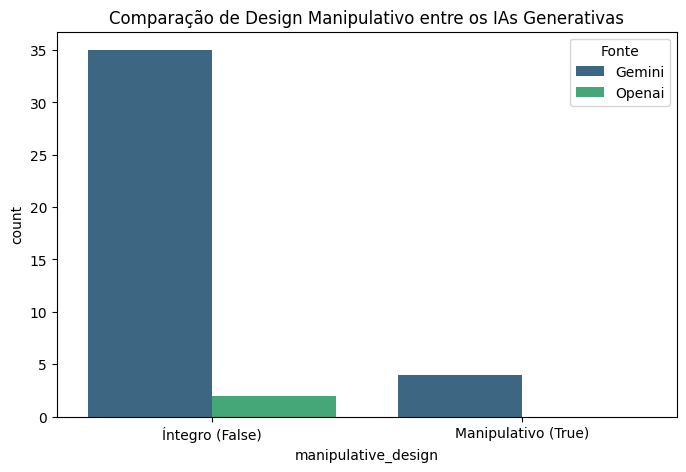

In [7]:
# 3. Criando o gráfico comparativo
df_final = pd.concat([df_Gemini, df_Openai])

plt.figure(figsize=(8, 5))
sns.countplot(data = df_final, x = 'manipulative_design', hue = 'Fonte', palette = 'viridis')

plt.title("Comparação de Design Manipulativo entre os IAs Generativas")
plt.xticks([0, 1], ['Íntegro (False)', 'Manipulativo (True)'])
plt.show()

In [8]:
df_Resultados = pd.read_excel(r"/workspaces/Dark_Patterns_Atv/Data/Resultados_esperados.xlsx")
df_Resultados.info()

<class 'pandas.DataFrame'>
RangeIndex: 27 entries, 0 to 26
Data columns (total 2 columns):
 #   Column                        Non-Null Count  Dtype
---  ------                        --------------  -----
 0   url                           27 non-null     str  
 1   manipulative_design_Buscados  27 non-null     bool 
dtypes: bool(1), str(1)
memory usage: 375.0 bytes


In [9]:
df_Gemini = df_Gemini.merge(df_Resultados, on='url', how='left')
df_Openai = df_Openai.merge(df_Resultados, on='url', how='left')

In [10]:
mask_validos_Gemini = df_Gemini['manipulative_design'].notna() & df_Gemini['manipulative_design_Buscados'].notna()

acertos_Gemini = (df_Gemini.loc[mask_validos_Gemini, 'manipulative_design'] == df_Gemini.loc[mask_validos_Gemini, 
                                                                                             'manipulative_design_Buscados']).sum()
total_Gemini = mask_validos_Gemini.sum()

proporcao_Gemini = acertos_Gemini / total_Gemini
percentual_Gemini = proporcao_Gemini * 100

if pd.isna(percentual_Gemini):
    percentual_Gemini = 0

print(f"Quantidade de acertos do Gemini {acertos_Gemini}")
print(f"Percentual de acertos do Gemini {percentual_Gemini}")

Quantidade de acertos do Gemini 18
Percentual de acertos do Gemini 64.28571428571429


In [11]:
erros_Gemini = total_Gemini - acertos_Gemini

labels_Gemini = ['Acertos', 'Erros']
valores_Gemini = [acertos_Gemini, erros_Gemini]

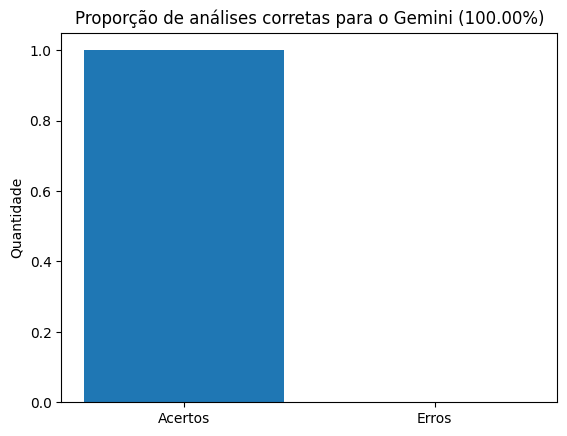

In [ ]:
plt.bar(labels_Gemini, valores_Gemini)
plt.title(f'Proporção de análises corretas para o Gemini ({percentual_Gemini:.2f}%)')
plt.ylabel('Quantidade')
plt.show()

In [ ]:
mask_validos_Openai = df_Openai['manipulative_design'].notna() & df_Openai['manipulative_design_Buscados'].notna()

acertos_Openai = (df_Openai.loc[mask_validos_Openai, 'manipulative_design'] == df_Openai.loc[mask_validos_Openai, 
                                                                                             'manipulative_design_Buscados']).sum()
total_Openai = mask_validos_Openai.sum()

proporcao_Openai = acertos_Openai / total_Openai
percentual_Openai = proporcao_Openai * 100

if pd.isna(percentual_Openai):
    percentual_Openai = 0

print(f"Quantidade de acertos do Openai {acertos_Openai}")
print(f"Percentual de acertos do Openai {percentual_Openai}")

Quantidade de acertos do Openai 0
Percentual de acertos do Openai 0


/tmp/ipykernel_5926/3962617796.py:7: RuntimeWarning: invalid value encountered in scalar divide
  proporcao_Openai = acertos_Openai / total_Openai


In [ ]:
erros_Openai = total_Openai - acertos_Openai

labels_Openai = ['Acertos', 'Erros']
valores_Openai = [acertos_Openai, erros_Gemini]

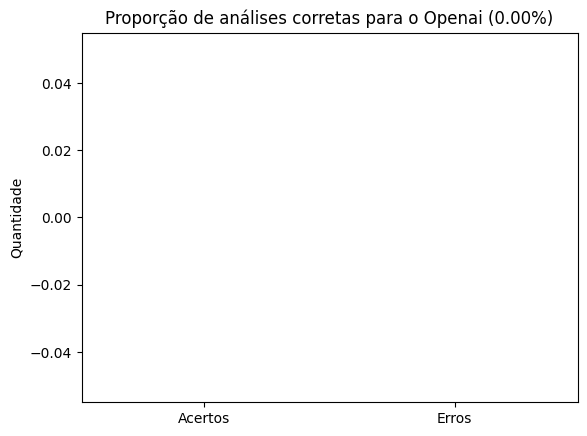

In [ ]:
plt.bar(labels_Openai, valores_Openai)
plt.title(f'Proporção de análises corretas para o Openai ({percentual_Openai:.2f}%)')
plt.ylabel('Quantidade')
plt.show()